# <span style="color:black; font-weight:bold;">Cross-modal alignment Breast cancer-HE-IF Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 8.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 8.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-modal Breast cancer data used in the tutorial are available at [Xenium_Breast_Cancer.h5ad](https://drive.google.com/file/d/1dVZbcULqrydCjfQen9p4eTl9fG_wTcrX/view?usp=sharing) , [Xenium_Breast_Cancer_Rep1_he_emb.h5ad](https://drive.google.com/file/d/1UYKGgVbViEDhPr815rhuct7K9WuxV-w4/view?usp=sharing) and [Xenium_Breast_Cancer_Rep1_if_emb.h5ad](https://drive.google.com/file/d/1qtgOK7wfxUQEYfM8ZQe2IEXUJYgUbvhv/view?usp=sharing) The raw data is from [10xGENOMICS](https://www.10xgenomics.com/) 
In this tutorial we apply MAPS to align Xenium to HE Breast cancer dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">Xenium(ST)</span>: 167,780 cells and 313 genes   
+ <span style="color:black; font-weight:bold;">HE</span>: 180,235 cells   
+ <span style="color:black; font-weight:bold;">IF</span>: 167,307 cells 

In [1]:
from MAPS.align import Multi_slices_rigid_alignment
from MAPS.utils import set_seed
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading Cross-modal Breast cancer data (Xenium, IF and HE)</span>
+ To ensure the accuracy of the scaling factor, we recommend using the HE slice as the target_adata for learning the scaling factor.

In [4]:
adata1=sc.read_h5ad('/home/dbj/LPcross/Data/HERNA/Xenium_breast_cancer/Xenium_Breast_Cancer_Rep1_he_emb.h5ad')
adata1.obs['batch']='HE'

adata2=sc.read_h5ad('/home/dbj/LPcross/Data/HERNA/Xenium_breast_cancer/Xenium_Breast_Cancer_Rep1_if_emb.h5ad')
adata2.obs['batch']='IF'

adata3=sc.read_h5ad('/home/dbj/SpaLP/Tutorialdata/Xenium_Breast_Cancer.h5ad')
adata3.obs['batch']='Xenium'

## <span style="color:black; font-weight:bold;">Spatial mapping of the Breast cancer before alignment</span>

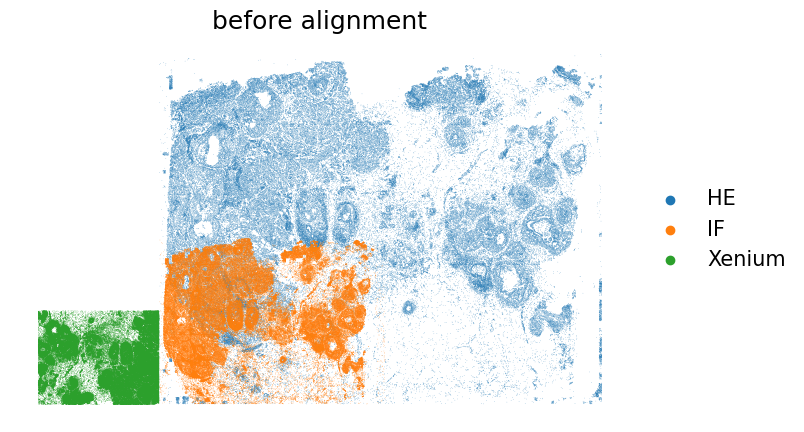

In [5]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 15
adata=sc.concat([adata1,adata2,adata3],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='before alignment',size=0.5,frameon=False)

## <span style="color:black; font-weight:bold;">Reference align using MAPS for multi-slices</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  
+ mode: 'reference' The slices are aligned to the reference target  
+ ref_idx: Reference target, the other slices are aligned to the target slice

### <span style="color:black; font-weight:bold;">Output</span>   
+ reference_list: A list of slices after reference align 

### <span style="color:black; font-weight:bold;">We set HE as the ref_idx</span>  

In [6]:
adata_list=[adata1,adata2,adata3]
reference_adata_list = Multi_slices_rigid_alignment(adata_list, mode='reference', ref_idx=0,epochs=5500, sample_size=20000, enable_scale=True, device=device)


--- Slice 1 is the reference, skipping ---

--- Aligning Slice 2 to Reference (Slice 1) ---
Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████████| 5500/5500 [01:41<00:00, 53.92it/s, Loss=63.29, Scale=2.030, Rot=-0.12°, Trans=(5920.0, 5842.3)]


Peak GPU memory usage: 4.869 GB
Scale factor: 2.030, Rotation angle: -0.11°, Translation (x, y): (5919.59, 5842.79)

--- Aligning Slice 3 to Reference (Slice 1) ---
Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████████| 5500/5500 [01:41<00:00, 54.19it/s, Loss=66.74, Scale=2.747, Rot=-179.77°, Trans=(16289.0, 9710.0)]


Peak GPU memory usage: 4.869 GB
Scale factor: 2.747, Rotation angle: -179.72°, Translation (x, y): (16289.86, 9710.71)

--- All slices have been aligned! ---


## <span style="color:black; font-weight:bold;">2D spatial mapping of the reference alignment result for breast cancer</span>

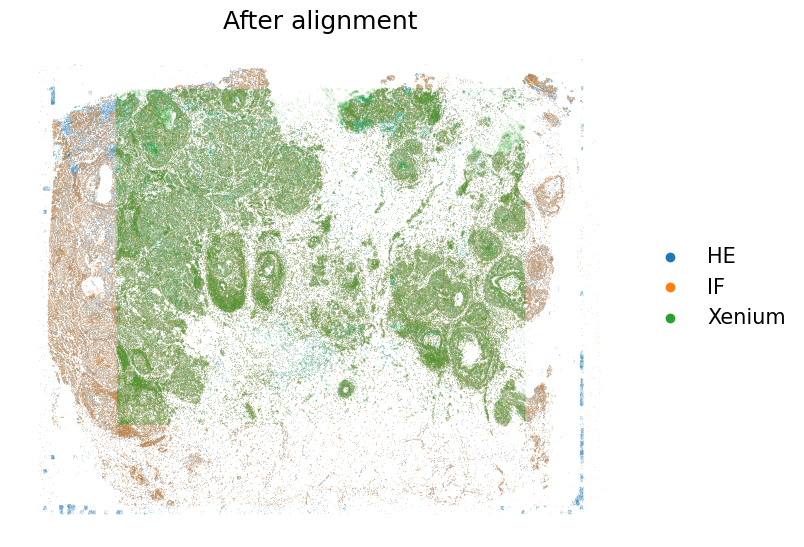

In [11]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (8,6.5)
plt.rcParams['font.size'] = 15
adata=sc.concat(reference_adata_list,join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='After alignment',size=0.7,alpha=0.7,frameon=False)